Load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("medical_eligibility_dataset.csv")

# Preview dataset
df.head()

,Donor_ID,Full_Name,Gender,Age,Blood_Group,Contact_Number,Email,City,State,Country,Last_Donation_Date,Total_Donations,Eligible_for_Donation,Medical_Condition,Weight_kg,Hemoglobin_g_dL,Donation_Center,Registration_Date
0,DNR000001,Sangeeta Menon,Female,38,O+,1819600042,sangeeta.menon8280@gmail.com,Kolkata,West Bengal,India,07-10-2025,1,Yes,NaN,66.6,13.6,Red Cross Blood Bank,02-07-2021
1,DNR000002,Meena Iyer,Female,49,B+,265423420,meena.iyer6225@gmail.com,Jaipur,Rajasthan,India,08-11-2020,1,No,Hypertension,70.8,14.0,Metro Blood Bank,03-03-2023
2,DNR000003,Priya Nair,Female,29,B+,1849593012,priya.nair4742@gmail.com,Gurgaon,Haryana,India,12-04-2025,2,No,Diabetes,73.4,12.5,Fortis Blood Bank,15-10-2015
3,DNR000004,Vijay Kapoor,Male,29,O+,3419283185,vijay.kapoor4423@gmail.com,Thiruvananthapuram,Kerala,India,21-02-2025,1,Yes,NaN,57.9,14.8,NABL Blood Centre,09-05-2022
4,DNR000005,Rahul Iyer,Male,27,A+,6413953676,rahul.iyer2341@gmail.com,Bhopal,Madhya Pradesh,India,18-04-2024,1,Yes,NaN,74.0,17.1,NABL Blood Centre,13-07-2022


check structure

In [3]:
df.shape

(10000, 18)

Inspect column information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Donor_ID               10000 non-null  str    
 1   Full_Name              10000 non-null  str    
 2   Gender                 10000 non-null  str    
 3   Age                    10000 non-null  int64  
 4   Blood_Group            10000 non-null  str    
 5   Contact_Number         10000 non-null  int64  
 6   Email                  10000 non-null  str    
 7   City                   10000 non-null  str    
 8   State                  10000 non-null  str    
 9   Country                10000 non-null  str    
 10  Last_Donation_Date     10000 non-null  str    
 11  Total_Donations        10000 non-null  int64  
 12  Eligible_for_Donation  10000 non-null  str    
 13  Medical_Condition      2195 non-null   str    
 14  Weight_kg              10000 non-null  float64
 15  Hemoglobin_g_d

Check Missing Values

In [5]:
df.isnull().sum()

Donor_ID                    0
Full_Name                   0
Gender                      0
Age                         0
Blood_Group                 0
Contact_Number              0
Email                       0
City                        0
State                       0
Country                     0
Last_Donation_Date          0
Total_Donations             0
Eligible_for_Donation       0
Medical_Condition        7805
Weight_kg                   0
Hemoglobin_g_dL             0
Donation_Center             0
Registration_Date           0
dtype: int64

Inspect target variable distribution

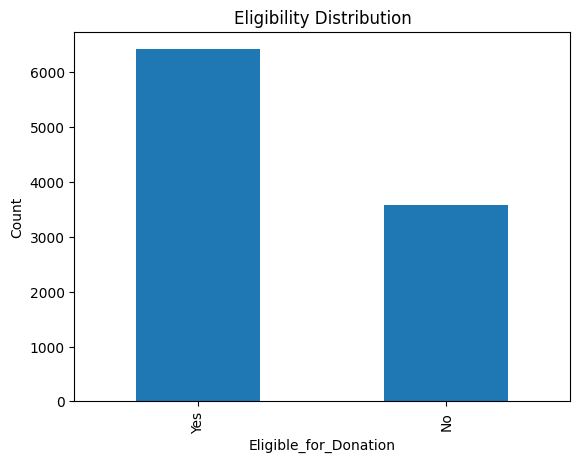

In [6]:
df["Eligible_for_Donation"].value_counts()

df["Eligible_for_Donation"].value_counts().plot(kind="bar")
plt.title("Eligibility Distribution")
plt.ylabel("Count")
plt.show()

Analyze numerical feature distributions

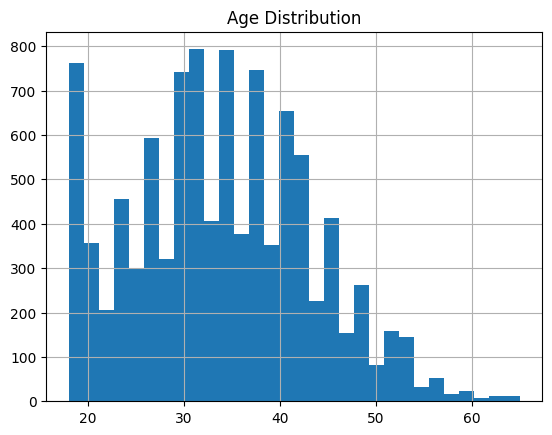

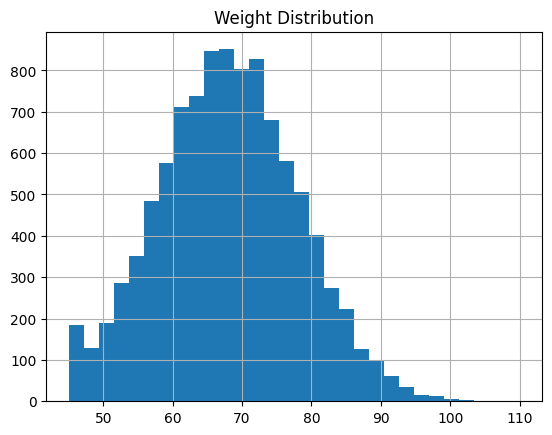

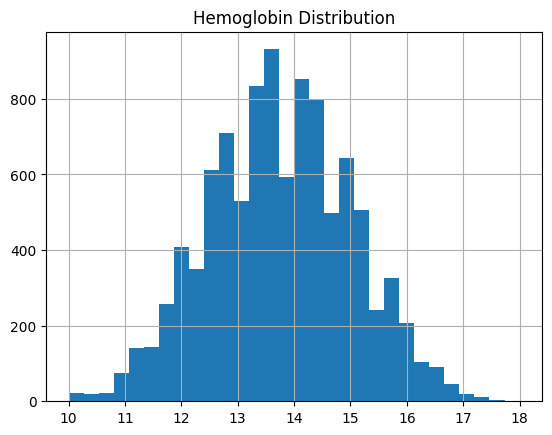

In [7]:
# Analyze Age distribution
df["Age"].describe()

df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

# Analyze Weight distribution
df["Weight_kg"].describe()

df["Weight_kg"].hist(bins=30)
plt.title("Weight Distribution")
plt.show()

# Analyze Hemoglobin distribution
df["Hemoglobin_g_dL"].describe()

df["Hemoglobin_g_dL"].hist(bins=30)
plt.title("Hemoglobin Distribution")
plt.show()

Analyze categorical variables

In [8]:
# Gender distribution
df["Gender"].value_counts()

# Check eligibility by gender:
pd.crosstab(df["Gender"], df["Eligible_for_Donation"])

# Blood group distribution
df["Blood_Group"].value_counts()

# Medical condition impact
df["Medical_Condition"].value_counts()

# Eligibility vs condition
pd.crosstab(df["Medical_Condition"], df["Eligible_for_Donation"])




Eligible_for_Donation,No
Medical_Condition,
Anemia,469
Asthma,308
Cardiac issues,100
Diabetes,388
Hypertension,614
Infection (resolved),109
Recent Surgery,207


Donation history analysis

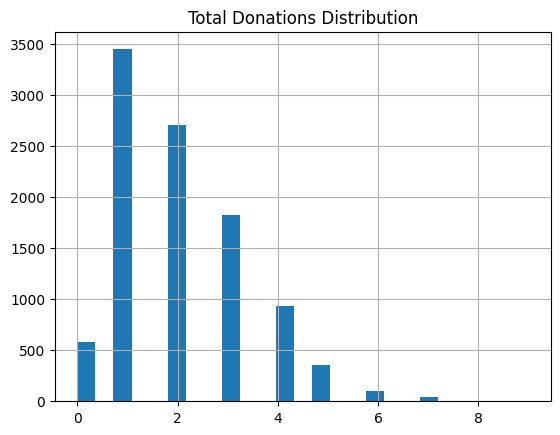

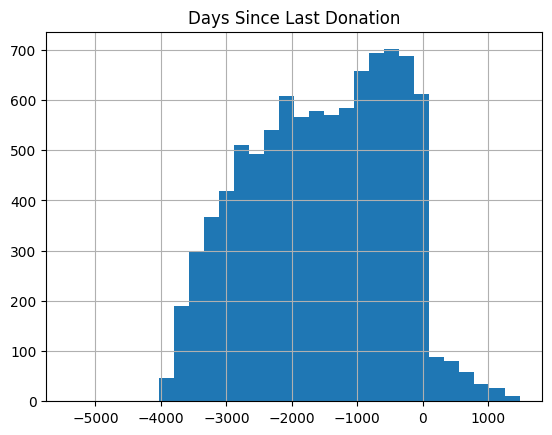

In [9]:
# Total donations
df["Total_Donations"].describe()

df["Total_Donations"].hist(bins=25)
plt.title("Total Donations Distribution")
plt.show()

pd.crosstab(df["Total_Donations"], df["Eligible_for_Donation"])


# Replace "Never" with missing value
df["Last_Donation_Date"] = df["Last_Donation_Date"].replace("Never", pd.NA)
df["Registration_Date"] = df["Registration_Date"].replace("Never", pd.NA)


# Convert mixed date formats safely
df["Last_Donation_Date"] = pd.to_datetime(
    df["Last_Donation_Date"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)

df["Registration_Date"] = pd.to_datetime(
    df["Registration_Date"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)


# Create feature
df["Days_Since_Last_Donation"] = (
    df["Registration_Date"] - df["Last_Donation_Date"]
).dt.days


# For people who have never donated before
df["Never_Donated_Before"] = df["Last_Donation_Date"].isna().astype(int)


# Plot
df["Days_Since_Last_Donation"].hist(bins=30)
plt.title("Days Since Last Donation")
plt.show()

Feature correlation analysis

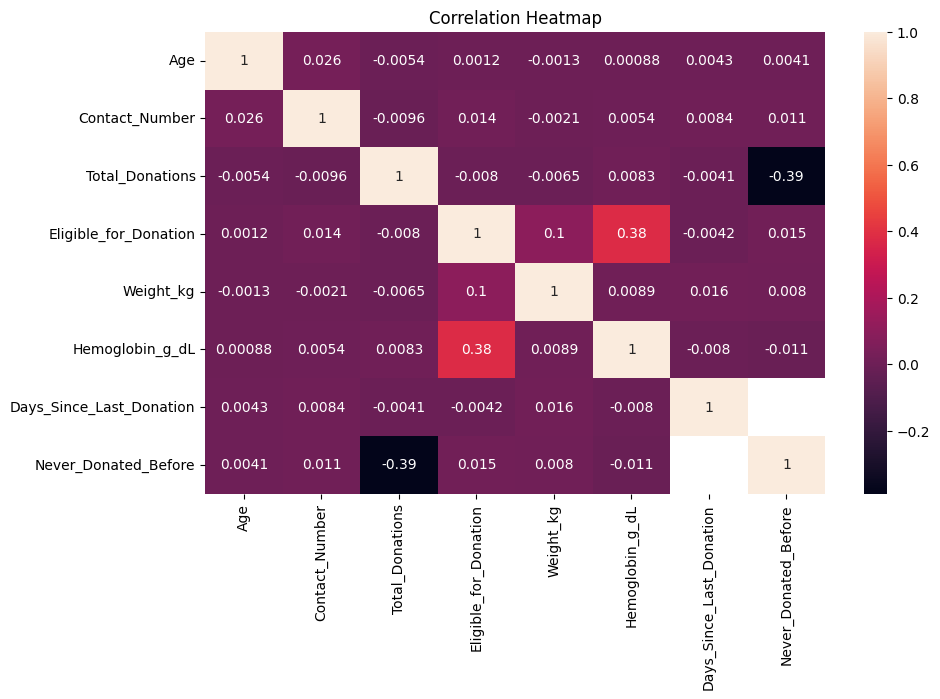

In [10]:
df["Eligible_for_Donation"] = df["Eligible_for_Donation"].map({
    "Yes": 1,
    "No": 0
})

df.corr(numeric_only=True)

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Eligibility vs hemoglobin (critical medical rule check)

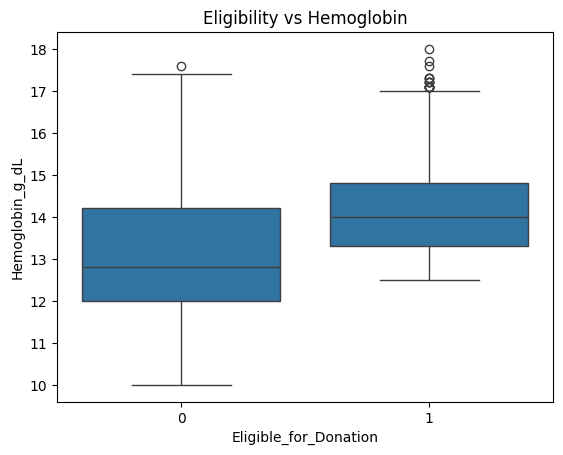

In [11]:
sns.boxplot(
    x="Eligible_for_Donation",
    y="Hemoglobin_g_dL",
    data=df
)
plt.title("Eligibility vs Hemoglobin")
plt.show()

Eligibility vs weight

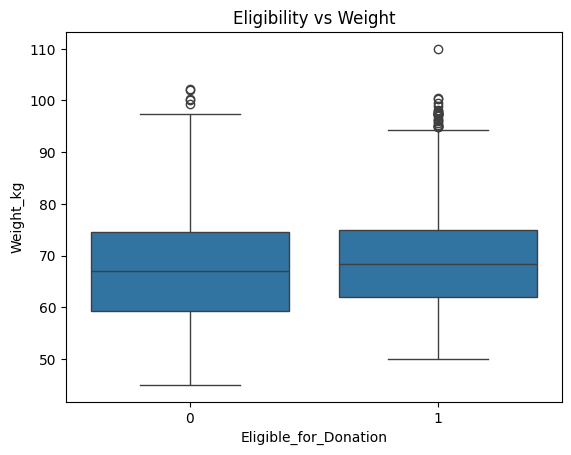

In [12]:
sns.boxplot(
    x="Eligible_for_Donation",
    y="Weight_kg",
    data=df
)
plt.title("Eligibility vs Weight")
plt.show()

Eligibility vs age

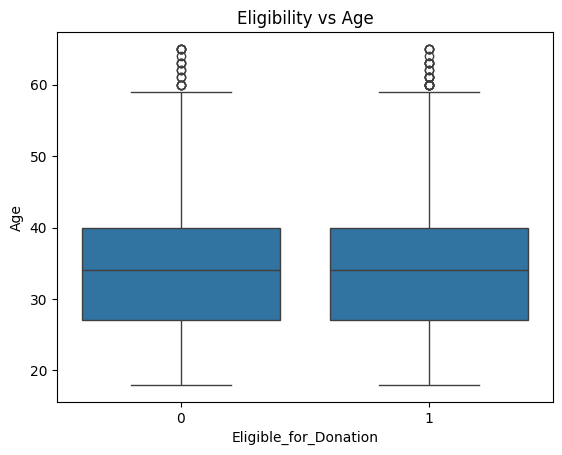

In [13]:
sns.boxplot(
    x="Eligible_for_Donation",
    y="Age",
    data=df
)
plt.title("Eligibility vs Age")
plt.show()

## Eligibility Model Feature Engineering + Model Selection

Hemoglobin status feature

In [14]:
df["Hemoglobin_Status"] = np.where(
    df["Hemoglobin_g_dL"] >= 12.5,
    "Normal",
    "Low"
)

Weight eligibility status

In [15]:
df["Weight_Status"] = np.where(
    df["Weight_kg"] >= 50,
    "Eligible",
    "Underweight"
)

Age eligibility group

In [16]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,18,65,100],
    labels=["Underage","Eligible_Age","Overage"]
)

Donation interval eligibility flag

In [17]:
df["Interval_Eligible"] = np.where(
    df["Days_Since_Last_Donation"] >= 56,
    1,
    0
)

Medical condition risk encoding

In [18]:
high_risk_conditions = ["HIV","Hepatitis B","Hepatitis C"]

df["Medical_Risk_Level"] = df["Medical_Condition"].apply(
    lambda x: "High" if x in high_risk_conditions else "Normal"
)

Encode categorical variables

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Blood_Group"] = le.fit_transform(df["Blood_Group"])
df["Medical_Condition"] = le.fit_transform(df["Medical_Condition"])

Define feature matrix

In [20]:
X = df.drop(columns=["Eligible_for_Donation"])
y = df["Eligible_for_Donation"]

## Train baseline eligibility model

In [22]:
# Check all columns first
df.columns

# Columns to remove from model training
columns_to_drop = [
    "Eligible_for_Donation",
    "Donor_ID",
    "Name",
    "Phone_Number",
    "Email",
    "Last_Donation_Date",
    "Registration_Date",
    "Donation_Center"
]

# Drop only columns that actually exist in the dataset
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=columns_to_drop)
y = df["Eligible_for_Donation"]

# Confirm remaining columns
X.head()

# One-hot encode all remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(0)

# Confirm final model-ready data
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 559 entries, Gender to Age_Group_Overage
dtypes: bool(548), float64(3), int64(8)
memory usage: 6.1 MB


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Confusion Matrix:
[[ 717    0]
 [   0 1283]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       717
           1       1.00      1.00      1.00      1283

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Confirm leakage

In [24]:
model.feature_importances_

import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)

Medical_Condition            0.468922
Hemoglobin_g_dL              0.172079
Hemoglobin_Status_Normal     0.137168
Weight_kg                    0.042666
Weight_Status_Underweight    0.036085
Gender                       0.022671
Contact_Number               0.010324
Days_Since_Last_Donation     0.009612
Age                          0.007872
Total_Donations              0.004872
Blood_Group                  0.004313
Full_Name_Richa Chopra       0.001113
State_Gujarat                0.001015
State_Maharashtra            0.000902
State_Uttar Pradesh          0.000823
dtype: float64

extract the actual eligibility rules hidden in the dataset

In [25]:
pd.crosstab(df["Hemoglobin_Status"], df["Eligible_for_Donation"])

pd.crosstab(df["Weight_Status"], df["Eligible_for_Donation"])

pd.crosstab(df["Interval_Eligible"], df["Eligible_for_Donation"])

pd.crosstab(df["Medical_Condition"], df["Eligible_for_Donation"])

Eligible_for_Donation,0,1
Medical_Condition,,
0,469,0
1,308,0
2,100,0
3,388,0
4,614,0
5,109,0
6,207,0
7,1389,6416


Drop identity leakage columns

In [29]:
# Drop columns that should not enter the model
columns_to_drop = [
    "Eligible_for_Donation",
    "Full_Name",
    "Contact_Number",
    "Email",
    "Donor_ID",
    "State",
    "Last_Donation_Date",
    "Registration_Date",
    "Donation_Center"
]

columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=columns_to_drop)
y = df["Eligible_for_Donation"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Fill missing numeric values
X = X.fillna(0)

# Confirm no datetime columns remain
print(X.dtypes)

Gender                         int64
Age                            int64
Blood_Group                    int64
Total_Donations                int64
Medical_Condition              int64
Weight_kg                    float64
Hemoglobin_g_dL              float64
Days_Since_Last_Donation     float64
Never_Donated_Before           int64
Interval_Eligible              int64
City_Bengaluru                  bool
City_Bhopal                     bool
City_Chennai                    bool
City_Delhi                      bool
City_Gurgaon                    bool
City_Hyderabad                  bool
City_Jaipur                     bool
City_Kanpur                     bool
City_Kolkata                    bool
City_Lucknow                    bool
City_Mohali                     bool
City_Mumbai                     bool
City_Nagpur                     bool
City_Patna                      bool
City_Pune                       bool
City_Surat                      bool
City_Thiruvananthapuram         bool
C

Rebuild feature matrix

In [30]:
X = df.drop(columns=["Eligible_for_Donation"])
y = df["Eligible_for_Donation"]

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

In [32]:
# Find columns still containing datetime / Timestamp values
datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()

print("Datetime columns still in X:")
print(datetime_cols)

Datetime columns still in X:
['Registration_Date']


In [33]:
# Drop any datetime columns still remaining
X = X.drop(columns=datetime_cols)

# Confirm
print(X.dtypes)

Gender                                         int64
Age                                            int64
Blood_Group                                    int64
Last_Donation_Date                            object
Total_Donations                                int64
Medical_Condition                              int64
Weight_kg                                    float64
Hemoglobin_g_dL                              float64
Days_Since_Last_Donation                     float64
Never_Donated_Before                           int64
Interval_Eligible                              int64
City_Bengaluru                                  bool
City_Bhopal                                     bool
City_Chennai                                    bool
City_Delhi                                      bool
City_Gurgaon                                    bool
City_Hyderabad                                  bool
City_Jaipur                                     bool
City_Kanpur                                   

In [36]:
# Remove columns that should not be used for training
bad_cols = [
    "Eligible_for_Donation",
    "Full_Name",
    "Contact_Number",
    "Email",
    "Donor_ID",
    "State",
    "Last_Donation_Date",
    "Registration_Date",
    "Donation_Center"
]

bad_cols = [col for col in bad_cols if col in df.columns]

X = df.drop(columns=bad_cols)
y = df["Eligible_for_Donation"]

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Remove any remaining datetime columns, just in case
datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns
X = X.drop(columns=datetime_cols)

# Fill missing values
X = X.fillna(0)

# Confirm Last_Donation_Date is gone
print("Last_Donation_Date" in X.columns)
print(X.dtypes)

False
Gender                         int64
Age                            int64
Blood_Group                    int64
Total_Donations                int64
Medical_Condition              int64
Weight_kg                    float64
Hemoglobin_g_dL              float64
Days_Since_Last_Donation     float64
Never_Donated_Before           int64
Interval_Eligible              int64
City_Bengaluru                  bool
City_Bhopal                     bool
City_Chennai                    bool
City_Delhi                      bool
City_Gurgaon                    bool
City_Hyderabad                  bool
City_Jaipur                     bool
City_Kanpur                     bool
City_Kolkata                    bool
City_Lucknow                    bool
City_Mohali                     bool
City_Mumbai                     bool
City_Nagpur                     bool
City_Patna                      bool
City_Pune                       bool
City_Surat                      bool
City_Thiruvananthapuram         

## Retrain eligibility model

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Confusion Matrix:
[[ 717    0]
 [   0 1283]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       717
           1       1.00      1.00      1.00      1283

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [35]:
for col in X.columns:
    sample_value = X[col].dropna().iloc[0] if not X[col].dropna().empty else None
    if "Timestamp" in str(type(sample_value)):
        print(col, type(sample_value), sample_value)

Last_Donation_Date <class 'pandas.Timestamp'> 2025-10-07 00:00:00
